## Introduction

This in-class example demonstrates how you approach a new data set and conduct simple data analysis.

What you need to know:  
- Statsmodels and pandas modules in python
- Theoretical concepts on statistical moments
- Theoretical concepts on simple linear regression model

The list of [references](#References) for detailed concepts and techniques used in this exerise.
***

## Content
- [Load the required modules](#Load-the-required-modules)
- [Data check and summary statistics](#Data-check-and-summary-statistics)
- [Simple Linear Regression Model](#Simple-Linear-Regression-Model) 
- [References](#References)

***
## Data Description

The data set is contained in a comma-separated value (csv) file named ```hprice1.csv``` with column headers. 

Description of the data is as follow:

| Name | Description |
| :--- | :--- |
| price    | house price, \$1000s |
| assess   | assessed value, \$1000s |
| bdrms    | number of bdrms |
| lotsize  | size of lot in square feet |
| sqrft    | size of house in square feet |
| colonial | =1 if home is colonial style |
| lprice   | log(price) |
| lassess  | log(assess) |
| llotsize | log(lotsize) |
| lsqrft   | log(sqrft) |

***
## Load the required modules

In [18]:
import numpy as np
import pandas as pd
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf

***
## Data check and summary statistics

#### Load the data set

In [19]:
hp_data = pd.read_csv("hprice1.csv")

#### Check if the data is properly imported

In [20]:
hp_data.head()

,price,assess,bdrms,lotsize,sqrft,colonial,lprice,lassess,llotsize,lsqrft
0,300.0,349.1,4,6126,2438,1,5.703783,5.855359,8.720297,7.798934
1,370.0,351.5,3,9903,2076,1,5.913503,5.862210,9.200593,7.638198
2,191.0,217.7,3,5200,1374,0,5.252274,5.383118,8.556414,7.225482
3,195.0,231.8,3,4600,1448,1,5.273000,5.445875,8.433811,7.277938
4,373.0,319.1,4,6095,2514,1,5.921578,5.765504,8.715224,7.829630


#### Get statistical moments

In [21]:
hp_data.describe()

,price,assess,bdrms,lotsize,sqrft,colonial,lprice,lassess,llotsize,lsqrft
count,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000
mean,293.546034,315.736364,3.568182,9019.863636,2013.693182,0.693182,5.633180,5.717994,8.905105,7.572610
std,102.713445,95.314437,0.841393,10174.150414,577.191583,0.463816,0.303573,0.262113,0.544060,0.258688
min,111.000000,198.700000,2.000000,1000.000000,1171.000000,0.000000,4.709530,5.291796,6.907755,7.065613
25%,230.000000,253.900000,3.000000,5732.750000,1660.500000,0.000000,5.438079,5.536940,8.653908,7.414873
50%,265.500000,290.200000,3.000000,6430.000000,1845.000000,1.000000,5.581613,5.670566,8.768719,7.520231
75%,326.250000,352.125000,4.000000,8583.250000,2227.000000,1.000000,5.787642,5.863982,9.057567,7.708266
max,725.000000,708.600000,7.000000,92681.000000,3880.000000,1.000000,6.586172,6.563291,11.436920,8.263591


#### Create a scatter plot to visualize the data

<Axes: xlabel='bdrms', ylabel='price'>

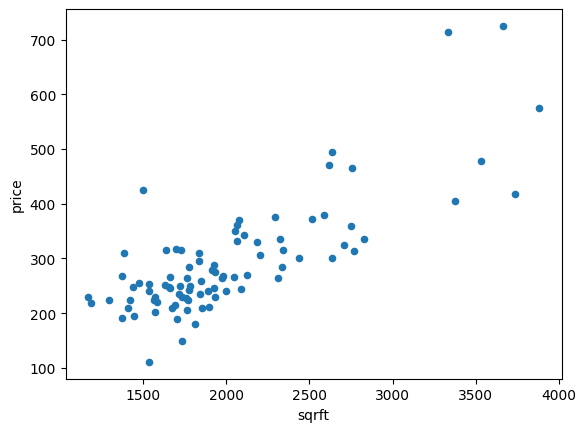

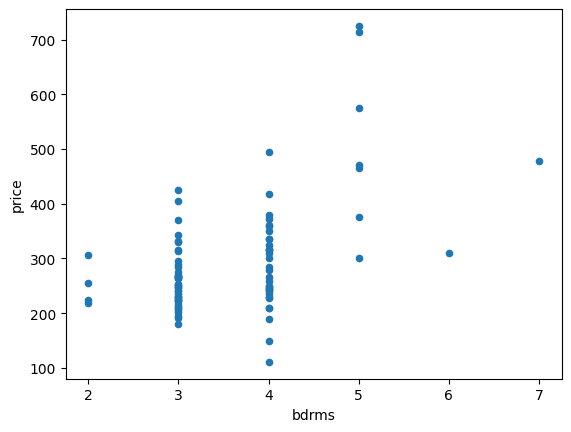

In [29]:
hp_data.plot.scatter('sqrft','price')
hp_data.plot.scatter('bdrms','price')

***
## Multiple Linear Regression Model

#### Model Estimation by the Ordinary Least Square (OLS) method

Estimate the model $$price = \beta_0 + \beta_1 sqrft + \beta_2 bdrms + u,$$
where price is the house price measured in thousands of dollars.

In [30]:
model = smf.ols(formula = 'price ~ sqrft + bdrms', data = hp_data).fit()

#### Get the estimation results

In [31]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.623
Method:                 Least Squares   F-statistic:                     72.96
Date:                Thu, 02 Oct 2025   Prob (F-statistic):           3.57e-19
Time:                        18:56:41   Log-Likelihood:                -488.00
No. Observations:                  88   AIC:                             982.0
Df Residuals:                      85   BIC:                             989.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -19.3150     31.047     -0.622      0.5

#### How would you interpret the results?

1. Write out the results in equation form.

price = -19.315 + 0.1284*sqrft + 15.1982*bdrms

2. What is the estimated increase in price for a house with one more bedroom, holding square footage constant?

In [ ]:
15198.2 dollars

3. What is the estimated increase in price for a house with an additional bedroom that is 140 square feet in size? Compare this to your answer above. 

In [ ]:
0.1284*140 + 15.1982*1 = 33.1742

33.1742

4. What percentage of the variation in price is explained by square footage and number of bedrooms?

In [ ]:
63.2%

5. The first house in the sample has $sqrft = 2,438$ and $bdrms = 4$. Find the predicted selling price for this house from the OLS regression line.

In [26]:
0.1284*2438 + 15.1982*4

373.832

6. The actual selling price of the first house in the sample was \$300,000 (price = 300). Find the residual for this house. Does it suggest that the buyer underpaid or overpaid for the house?

Yes, they overpaid for the house

***
## References

- Jeffrey M. Wooldridge (2019) "Introductory Econometrics: A Modern Approach, 7e" Chapter 3.

- The pandas development team (2020). "[pandas-dev/pandas: Pandas](https://pandas.pydata.org/)." Zenodo.
    
- Seabold, Skipper, and Josef Perktold (2010). "[statsmodels: Econometric and statistical modeling with python](https://www.statsmodels.org/stable/examples/notebooks/generated/ols.html)." Proceedings of the 9th Python in Science Conference.